In [1]:
#Load Data

import pandas as pd

df = pd.read_csv('accidents_sample.csv')
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [2]:
#Basic cleaning

df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50000 non-null  object 
 1   Source                 50000 non-null  object 
 2   Severity               50000 non-null  int64  
 3   Start_Time             50000 non-null  object 
 4   End_Time               50000 non-null  object 
 5   Start_Lat              50000 non-null  float64
 6   Start_Lng              50000 non-null  float64
 7   End_Lat                0 non-null      float64
 8   End_Lng                0 non-null      float64
 9   Distance(mi)           50000 non-null  float64
 10  Description            50000 non-null  object 
 11  Street                 50000 non-null  object 
 12  City                   50000 non-null  object 
 13  County                 50000 non-null  object 
 14  State                  50000 non-null  object 
 15  Zi

In [3]:
#Select important columns

df = df[['Start_Time','Severity','Weather_Condition','Visibility(mi)','Start_Lat','Start_Lng']]

In [4]:
#Convert Time

df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['Hour'] = df['Start_Time'].dt.hour

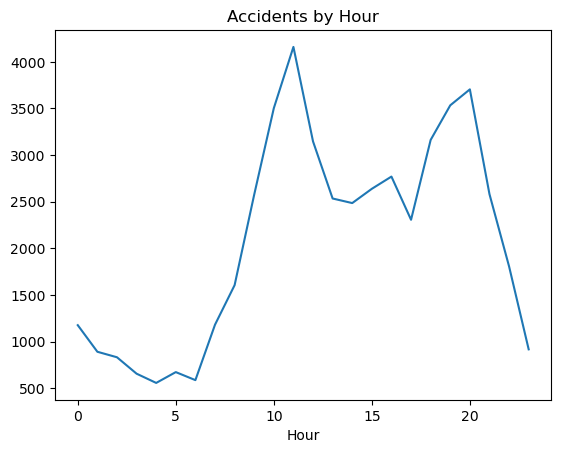

In [5]:
#Analysis

# Accidents by time

df['Hour'].value_counts().sort_index().plot(kind='line')
import matplotlib.pyplot as plt
plt.title('Accidents by Hour')
plt.savefig('accidents_by_hour.png')
plt.show()

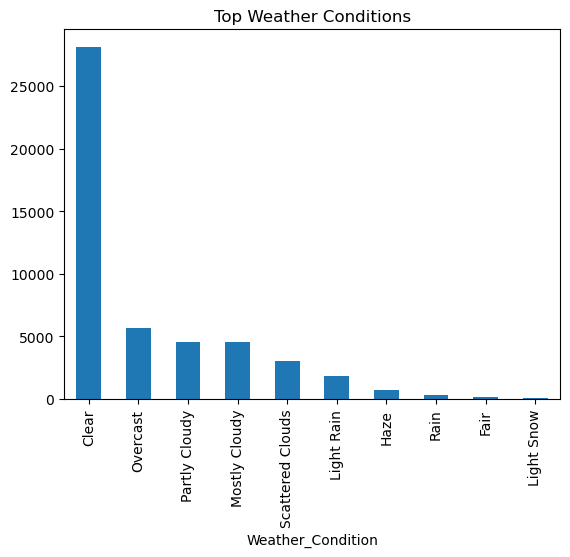

In [6]:
#Accidents by Weather

df['Weather_Condition'].value_counts().head(10).plot(kind='bar')
plt.title('Top Weather Conditions')
plt.savefig('weather_conditions.png')
plt.show()

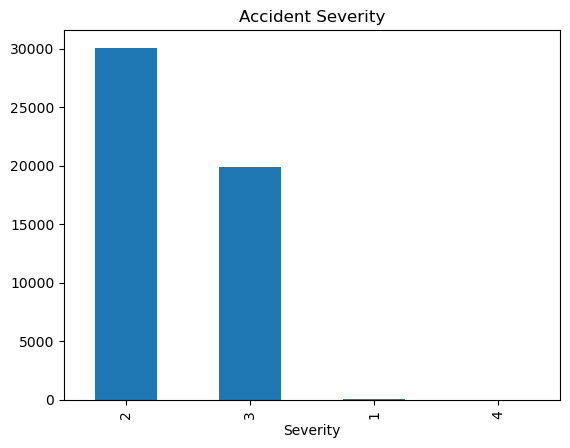

In [7]:
#Severity Distribution

df['Severity'].value_counts().plot(kind='bar')
plt.title('Accident Severity')
plt.savefig('severity.png')
plt.show()

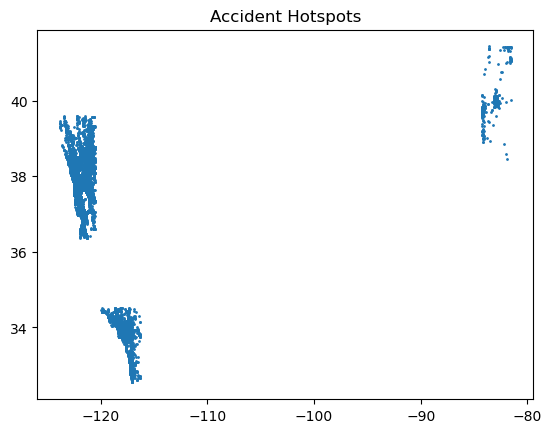

In [8]:
#HOTSPOT VISUALIZATION

import matplotlib.pyplot as plt

plt.scatter(df['Start_Lng'], df['Start_Lat'], s=1)
plt.title('Accident Hotspots')
plt.savefig('hotspots.png')
plt.show()